# Input Pipeline Visualization

End-to-end visualization of every stage from raw TFRecord to what the model actually sees:
1. **Raw parsed data** — mz/intensity after TFRecord parsing
2. **Filtering & normalization** — peak range filtering, top-k, neutral loss, normalization
3. **Valid mask & padding** — which peaks are real vs zero-padded
4. **Two-view augmentation** — masked view (view1) vs unmasked view (view2)
5. **Fused batch** — the [2B, N] tensors the encoder actually receives
6. **Fourier features** — what mz looks like after NeRF-style encoding

In [1]:
import sys, os
os.chdir(os.path.join(os.path.dirname(os.path.abspath('.')), ''))
sys.path.insert(0, os.path.abspath('..'))
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.patches import Patch
import torch

# Project imports
from input_pipeline import TfLightningDataModule, numpy_batch_to_torch, _NUM_PEAKS_OUTPUT
from configs.gems_a_50_mask import get_config

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

cfg = get_config()
dm = TfLightningDataModule(cfg, seed=42)
print(f"Train size: {dm.info['train_size']:,}")
print(f"Val size: {dm.info['validation_size']:,}")
print(f"Num peaks (output): {dm.info['num_peaks']}")
print(f"MZ representation: {dm.info['mz_representation']}")
print(f"Peak ordering: {cfg.peak_ordering}")

Train size: 39,854,312
Val size: 2,097,596
Num peaks (output): 60
MZ representation: neutral_loss
Peak ordering: mz


/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Raw Batch (Pre-Augmentation)

After TFRecord parsing, filtering, top-k selection, neutral-loss conversion, sorting, and normalization — but **before** two-view augmentation. This is what `_batched_parse_and_transform` produces.

In [2]:
# Build a dataset WITHOUT augmentation to see the raw parsed output
from input_pipeline import _build_dataset

raw_ds = _build_dataset(
    dm.gems_train_files,
    batch_size=16,
    shuffle_buffer=1000,
    seed=42,
    drop_remainder=True,
    tfrecord_buffer_size=dm.tfrecord_buffer_size,
    max_precursor_mz=dm.max_precursor_mz,
    include_fingerprint=False,
    intensity_scaling=dm.intensity_scaling,
    min_peak_intensity=dm.min_peak_intensity,
    mz_representation=dm.mz_representation,
    include_sigreg_augmentation=False,  # No augmentation
    sigreg_contiguous_mask_fraction=0.25,
    sigreg_contiguous_mask_min_len=1,
    sigreg_random_mask_prob=0.05,
    sigreg_mz_jitter_std=0.0001,
    sigreg_intensity_jitter_std=0.005,
    peak_ordering=cfg.peak_ordering,
)

raw_batch = next(raw_ds.as_numpy_iterator())
print("Raw batch keys:", list(raw_batch.keys()))
for k, v in raw_batch.items():
    print(f"  {k}: shape={v.shape}, dtype={v.dtype}, range=[{v.min():.4f}, {v.max():.4f}]")

Raw batch keys: ['peak_mz', 'peak_intensity', 'peak_valid_mask', 'precursor_mz', 'rt', 'mz', 'intensity']
  peak_mz: shape=(16, 60), dtype=float32, range=[0.0000, 0.7175]
  peak_intensity: shape=(16, 60), dtype=float32, range=[0.0000, 1.0000]
  peak_valid_mask: shape=(16, 60), dtype=bool, range=[0.0000, 1.0000]
  precursor_mz: shape=(16,), dtype=float32, range=[0.1140, 0.7986]
  rt: shape=(16,), dtype=float32, range=[14.6945, 717.8347]
  mz: shape=(16, 60), dtype=float32, range=[0.0000, 717.5189]
  intensity: shape=(16, 60), dtype=float32, range=[0.0000, 1.0000]


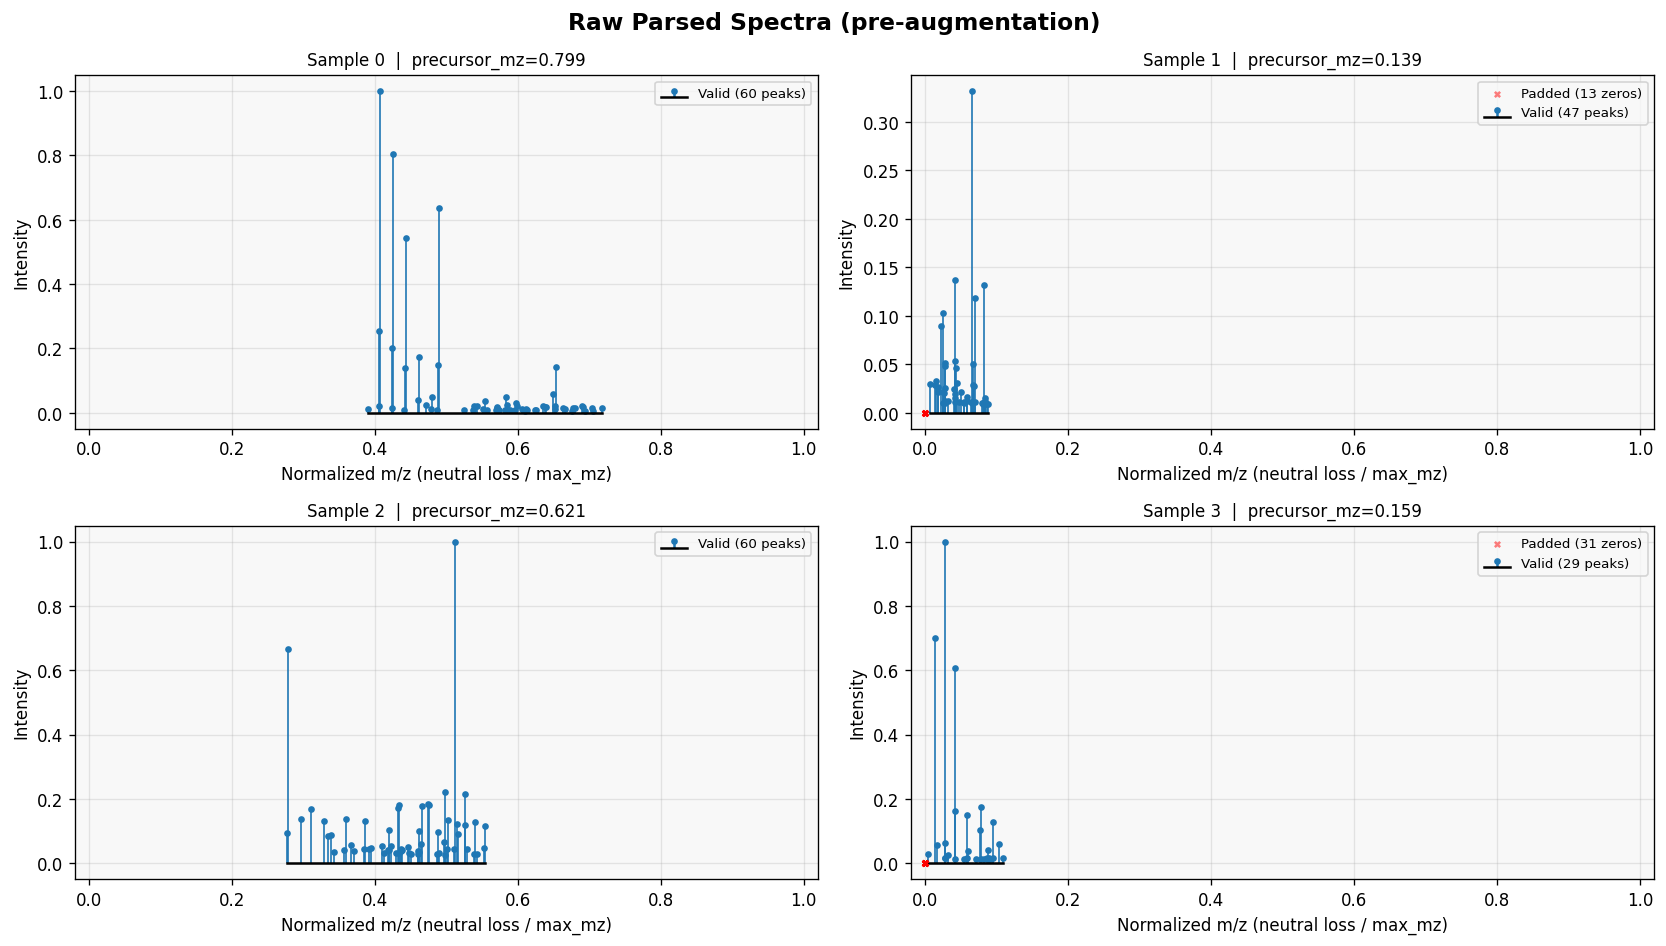

In [3]:
# Visualize 4 raw spectra: stem plots of mz vs intensity with valid mask overlay
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Raw Parsed Spectra (pre-augmentation)', fontsize=14, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    mz = raw_batch['peak_mz'][idx]       # normalized [0,1]
    intensity = raw_batch['peak_intensity'][idx]
    valid = raw_batch['peak_valid_mask'][idx]
    prec = raw_batch['precursor_mz'][idx]
    
    # Valid peaks
    v_idx = np.where(valid)[0]
    p_idx = np.where(~valid)[0]
    
    markerline, stemlines, baseline = ax.stem(
        mz[v_idx], intensity[v_idx],
        linefmt='C0-', markerfmt='C0o', basefmt='k-',
        label=f'Valid ({len(v_idx)} peaks)',
    )
    stemlines.set_linewidth(1.0)
    markerline.set_markersize(3)
    
    if len(p_idx) > 0:
        ax.scatter(mz[p_idx], intensity[p_idx], c='red', s=10, marker='x',
                   alpha=0.5, label=f'Padded ({len(p_idx)} zeros)', zorder=5)
    
    ax.set_title(f'Sample {idx}  |  precursor_mz={prec:.3f}', fontsize=10)
    ax.set_xlabel('Normalized m/z (neutral loss / max_mz)')
    ax.set_ylabel('Intensity')
    ax.legend(fontsize=8)
    ax.set_xlim(-0.02, 1.02)

plt.tight_layout()
plt.savefig('notebooks/fig_raw_spectra.png', bbox_inches='tight')
plt.show()

## 2. Valid Mask & Padding Distribution

How many of the 60 peak slots are actually filled vs zero-padded across the batch?

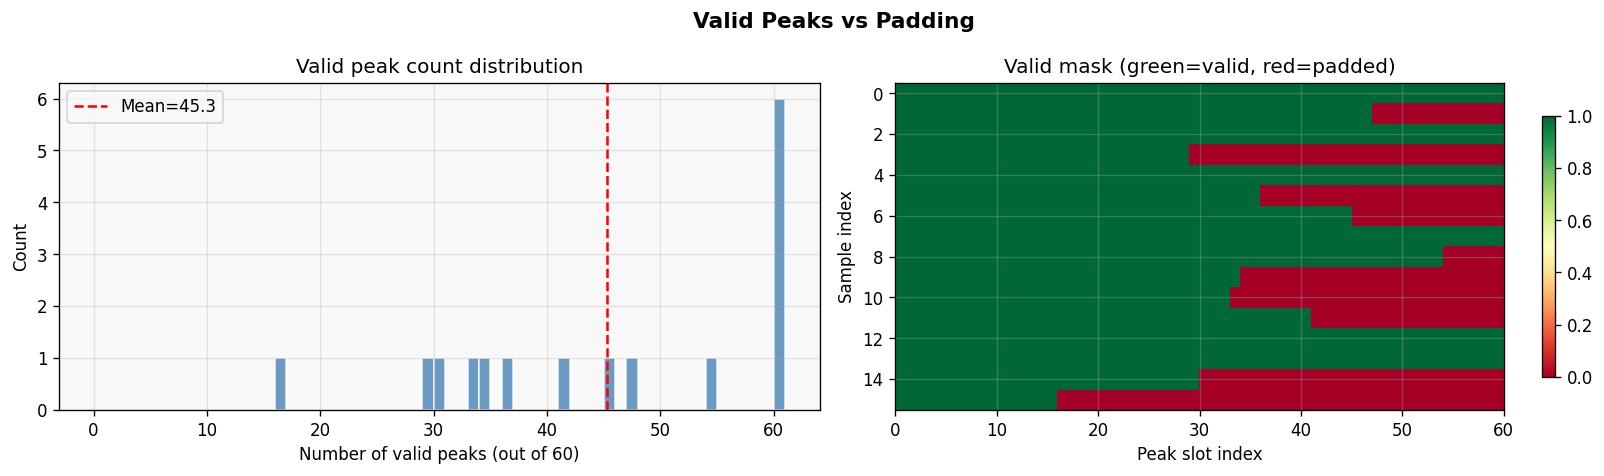

In [4]:
valid_counts = raw_batch['peak_valid_mask'].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Valid Peaks vs Padding', fontsize=13, fontweight='bold')

# Histogram of valid peak counts
ax = axes[0]
ax.hist(valid_counts, bins=range(0, _NUM_PEAKS_OUTPUT + 2), color='steelblue',
        edgecolor='white', alpha=0.8)
ax.axvline(valid_counts.mean(), color='red', ls='--', label=f'Mean={valid_counts.mean():.1f}')
ax.set_xlabel('Number of valid peaks (out of 60)')
ax.set_ylabel('Count')
ax.set_title('Valid peak count distribution')
ax.legend()

# Heatmap: each row is a sample, columns are peak slots, color = valid/padded
ax = axes[1]
im = ax.imshow(raw_batch['peak_valid_mask'][:16].astype(float),
               aspect='auto', cmap='RdYlGn', interpolation='nearest',
               extent=[0, _NUM_PEAKS_OUTPUT, 15.5, -0.5])
ax.set_xlabel('Peak slot index')
ax.set_ylabel('Sample index')
ax.set_title('Valid mask (green=valid, red=padded)')
plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig('notebooks/fig_valid_mask.png', bbox_inches='tight')
plt.show()

## 3. Two-View Augmentation: Masked vs Unmasked

Now apply the SIGReg augmentation. View 1 gets contiguous + random masking with jitter; View 2 gets jitter only.

In [5]:
# Build dataset WITH augmentation
aug_ds = _build_dataset(
    dm.gems_train_files,
    batch_size=16,
    shuffle_buffer=1000,
    seed=42,
    drop_remainder=True,
    tfrecord_buffer_size=dm.tfrecord_buffer_size,
    max_precursor_mz=dm.max_precursor_mz,
    include_fingerprint=False,
    intensity_scaling=dm.intensity_scaling,
    min_peak_intensity=dm.min_peak_intensity,
    mz_representation=dm.mz_representation,
    include_sigreg_augmentation=True,
    sigreg_contiguous_mask_fraction=cfg.sigreg_contiguous_mask_fraction,
    sigreg_contiguous_mask_min_len=cfg.sigreg_contiguous_mask_min_len,
    sigreg_random_mask_prob=cfg.sigreg_random_mask_prob,
    sigreg_mz_jitter_std=cfg.sigreg_mz_jitter_std,
    sigreg_intensity_jitter_std=cfg.sigreg_intensity_jitter_std,
    peak_ordering=cfg.peak_ordering,
)

aug_batch = next(aug_ds.as_numpy_iterator())
print("Augmented batch keys:", list(aug_batch.keys()))
print(f"\nFused tensors are [2*B, N] = [{aug_batch['fused_mz'].shape[0]}, {aug_batch['fused_mz'].shape[1]}]")
print(f"View1 masked fraction: {aug_batch['view1_masked_fraction']:.3f}")
for k in ['fused_mz', 'fused_intensity', 'fused_valid_mask', 'fused_original_valid_mask', 'fused_masked_positions', 'fused_precursor_mz']:
    v = aug_batch[k]
    print(f"  {k}: shape={v.shape}, dtype={v.dtype}")

# Check noise filling: fused_valid_mask should be all True, fused_original_valid_mask tracks real peaks
print(f"\nNoise filling active: fused_valid_mask all True = {aug_batch['fused_valid_mask'].all()}")
print(f"  fused_original_valid_mask True fraction: {aug_batch['fused_original_valid_mask'].mean():.3f}")

Augmented batch keys: ['peak_mz', 'peak_intensity', 'peak_valid_mask', 'precursor_mz', 'rt', 'mz', 'intensity', 'fused_mz', 'fused_intensity', 'fused_precursor_mz', 'fused_original_valid_mask', 'fused_masked_positions', 'fused_valid_mask', 'view1_masked_fraction']

Fused tensors are [2*B, N] = [32, 60]
View1 masked fraction: 0.280
  fused_mz: shape=(32, 60), dtype=float32
  fused_intensity: shape=(32, 60), dtype=float32
  fused_valid_mask: shape=(32, 60), dtype=bool
  fused_original_valid_mask: shape=(32, 60), dtype=bool
  fused_masked_positions: shape=(32, 60), dtype=bool
  fused_precursor_mz: shape=(32,), dtype=float32

Noise filling active: fused_valid_mask all True = True
  fused_original_valid_mask True fraction: 0.649


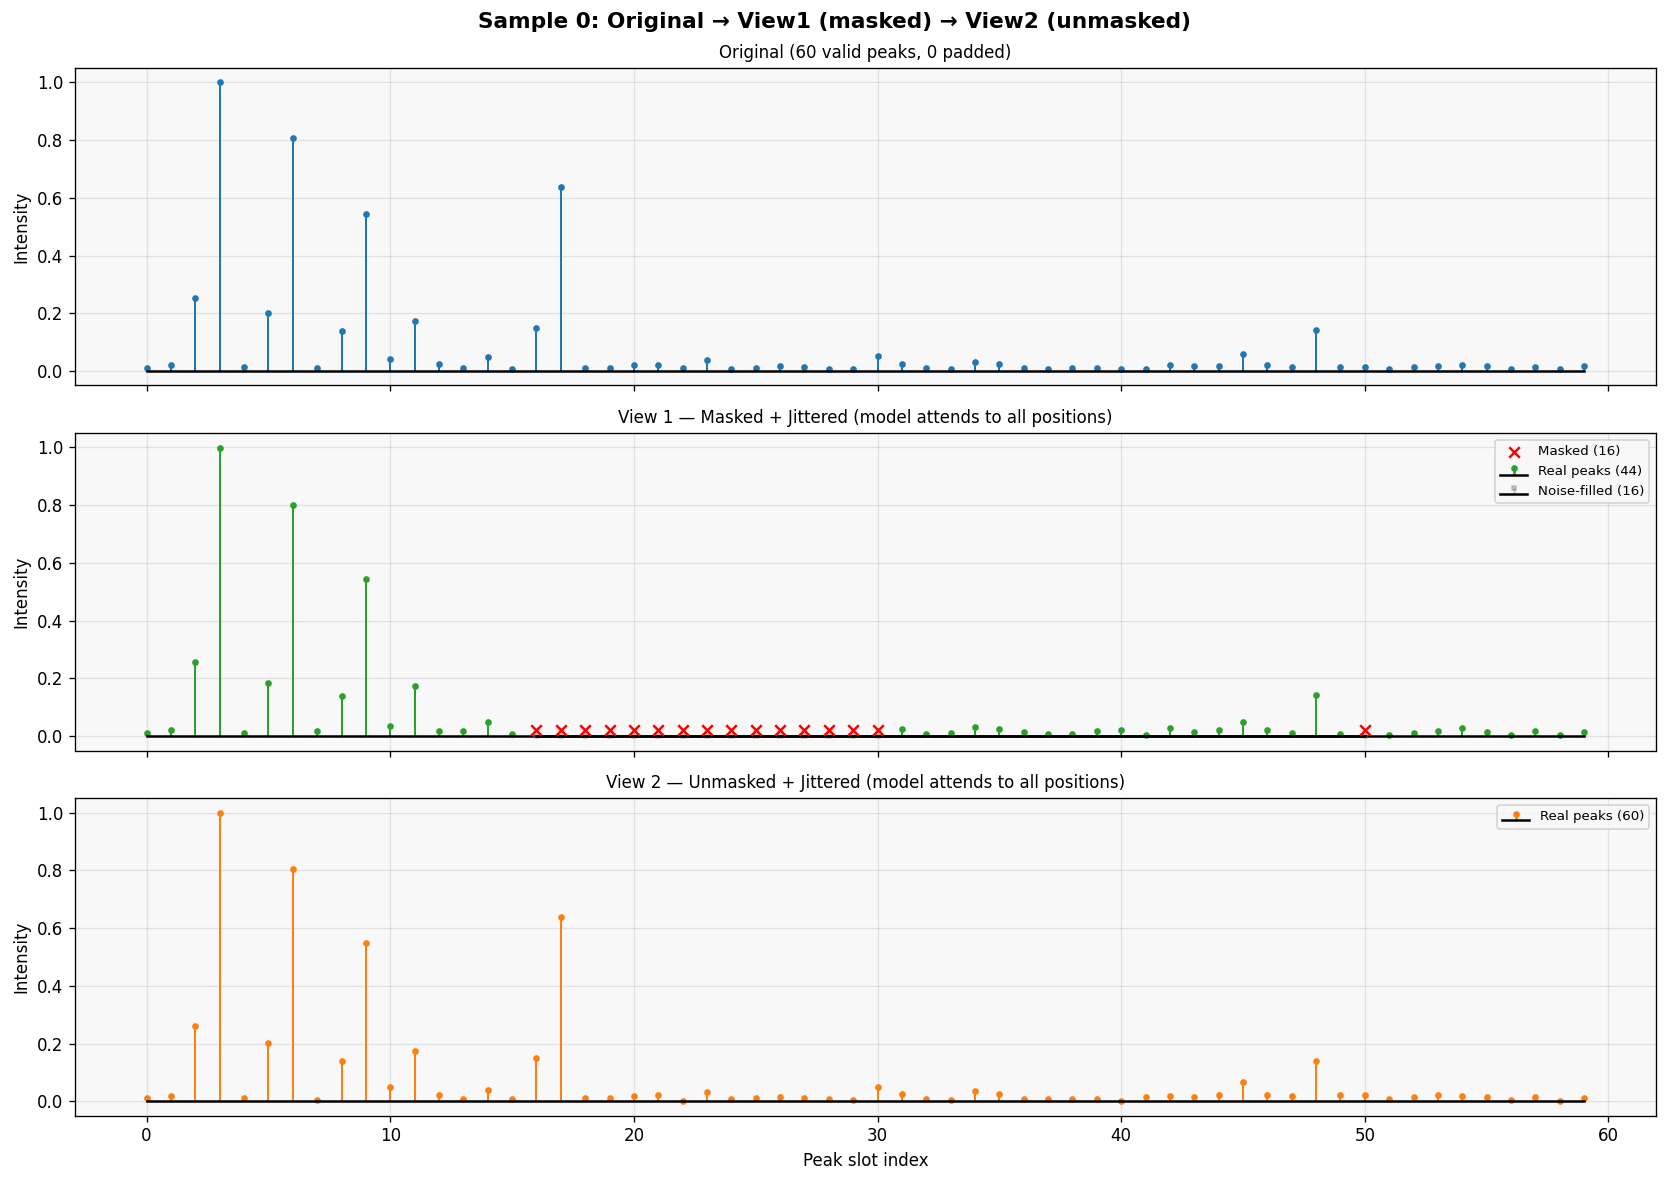

In [6]:
# Compare a single spectrum across: Original, View1 (masked), View2 (unmasked)
# Use fused_original_valid_mask for visualization (true peak vs noise boundary)
B = 16
sample_idx = 0

orig_mz = raw_batch['peak_mz'][sample_idx]
orig_int = raw_batch['peak_intensity'][sample_idx]
orig_valid = raw_batch['peak_valid_mask'][sample_idx]

# View1 is first B samples, View2 is next B samples in fused tensors
v1_mz = aug_batch['fused_mz'][sample_idx]  # view1
v1_int = aug_batch['fused_intensity'][sample_idx]
v1_orig_valid = aug_batch['fused_original_valid_mask'][sample_idx]
v1_masked = aug_batch['fused_masked_positions'][sample_idx]

v2_mz = aug_batch['fused_mz'][B + sample_idx]  # view2
v2_int = aug_batch['fused_intensity'][B + sample_idx]
v2_orig_valid = aug_batch['fused_original_valid_mask'][B + sample_idx]
v2_masked = aug_batch['fused_masked_positions'][B + sample_idx]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f'Sample {sample_idx}: Original → View1 (masked) → View2 (unmasked)', 
             fontsize=13, fontweight='bold')

# Original
ax = axes[0]
v_mask = orig_valid.astype(bool)
markerline, stemlines, baseline = ax.stem(
    np.where(v_mask)[0], orig_int[v_mask],
    linefmt='C0-', markerfmt='C0o', basefmt='k-'
)
stemlines.set_linewidth(1.2)
markerline.set_markersize(3)
ax.set_ylabel('Intensity')
ax.set_title(f'Original ({v_mask.sum()} valid peaks, {(~v_mask).sum()} padded)', fontsize=10)

# View 1 (masked) — use original valid mask to distinguish real vs noise peaks
ax = axes[1]
v1_ov = v1_orig_valid.astype(bool)
v1_m = v1_masked.astype(bool)
# Show surviving real peaks (originally valid and not masked)
surviving = v1_ov & ~v1_m
noise_filled = ~v1_ov  # positions filled with noise
if surviving.any():
    markerline, stemlines, baseline = ax.stem(
        np.where(surviving)[0], v1_int[surviving],
        linefmt='C2-', markerfmt='C2o', basefmt='k-',
        label=f'Real peaks ({surviving.sum()})',
    )
    stemlines.set_linewidth(1.2)
    markerline.set_markersize(3)
# Show noise-filled positions
if noise_filled.any():
    markerline2, stemlines2, baseline2 = ax.stem(
        np.where(noise_filled)[0], v1_int[noise_filled],
        linefmt='C7-', markerfmt='C7s', basefmt='k-',
        label=f'Noise-filled ({noise_filled.sum()})',
    )
    stemlines2.set_linewidth(0.6)
    stemlines2.set_alpha(0.4)
    markerline2.set_markersize(2)
    markerline2.set_alpha(0.4)
# Show masked positions
if v1_m.any():
    ax.scatter(np.where(v1_m)[0], np.full(v1_m.sum(), 0.02), c='red', s=40,
              marker='x', linewidths=1.5, label=f'Masked ({v1_m.sum()})', zorder=5)
ax.set_ylabel('Intensity')
ax.set_title(f'View 1 — Masked + Jittered (model attends to all positions)', fontsize=10)
ax.legend(fontsize=8)

# View 2 (unmasked) — use original valid mask
ax = axes[2]
v2_ov = v2_orig_valid.astype(bool)
v2_noise = ~v2_ov
if v2_ov.any():
    markerline, stemlines, baseline = ax.stem(
        np.where(v2_ov)[0], v2_int[v2_ov],
        linefmt='C1-', markerfmt='C1o', basefmt='k-',
        label=f'Real peaks ({v2_ov.sum()})',
    )
    stemlines.set_linewidth(1.2)
    markerline.set_markersize(3)
if v2_noise.any():
    markerline2, stemlines2, baseline2 = ax.stem(
        np.where(v2_noise)[0], v2_int[v2_noise],
        linefmt='C7-', markerfmt='C7s', basefmt='k-',
        label=f'Noise-filled ({v2_noise.sum()})',
    )
    stemlines2.set_linewidth(0.6)
    stemlines2.set_alpha(0.4)
    markerline2.set_markersize(2)
    markerline2.set_alpha(0.4)
ax.set_xlabel('Peak slot index')
ax.set_ylabel('Intensity')
ax.set_title(f'View 2 — Unmasked + Jittered (model attends to all positions)', fontsize=10)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('notebooks/fig_two_views.png', bbox_inches='tight')
plt.show()

## 4. Masking Pattern Detail

Visualize the contiguous + random masking pattern across multiple samples.

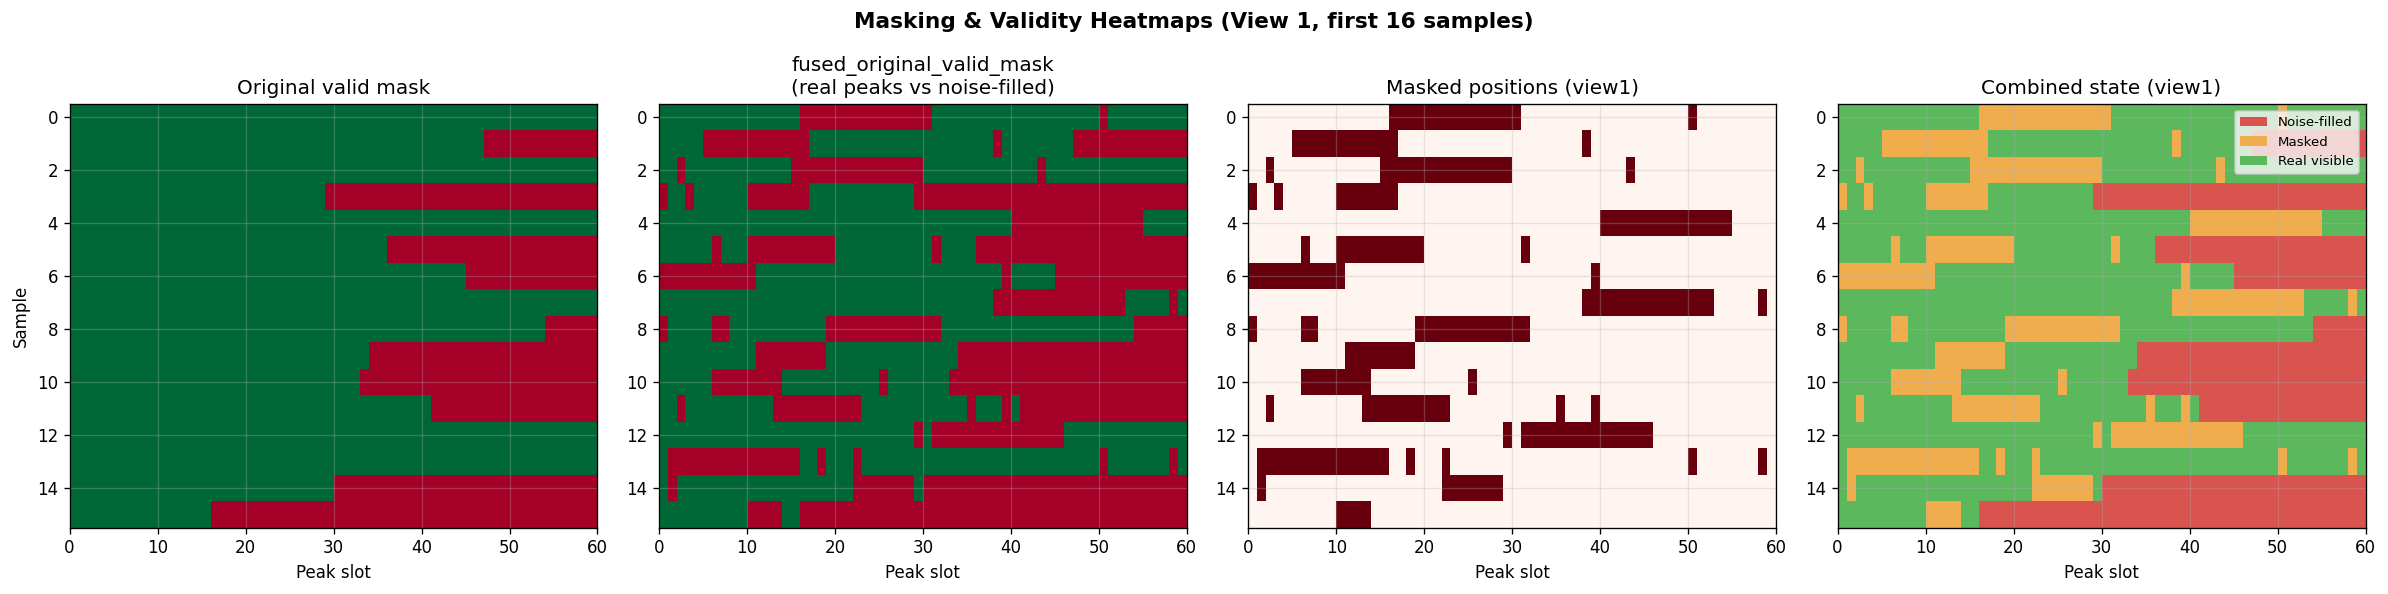

Note: fused_valid_mask is all True (model attends to all positions including noise)
      fused_original_valid_mask tracks the real peak boundary for analysis


In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Masking & Validity Heatmaps (View 1, first 16 samples)', fontsize=13, fontweight='bold')

N = _NUM_PEAKS_OUTPUT
v1_orig_valid_all = aug_batch['fused_original_valid_mask'][:B]  # [B, N] — true valid/noise boundary
v1_model_valid_all = aug_batch['fused_valid_mask'][:B]          # [B, N] — what model sees (all True)
v1_masked_all = aug_batch['fused_masked_positions'][:B]         # [B, N]
orig_valid_all = raw_batch['peak_valid_mask'][:B]

# Combined state: 0=noise-filled, 1=masked, 2=real peak (visible), 3=masked real peak
combined = np.zeros_like(orig_valid_all, dtype=float)
combined[v1_orig_valid_all.astype(bool) & ~v1_masked_all.astype(bool)] = 2  # real, visible
combined[v1_masked_all.astype(bool)] = 1  # masked
# noise-filled stays 0

from matplotlib.colors import ListedColormap
cmap3 = ListedColormap(['#d9534f', '#f0ad4e', '#5cb85c'])  # red=noise, orange=masked, green=real visible

# (a) Original valid mask (pre-augmentation)
ax = axes[0]
ax.imshow(orig_valid_all.astype(float), aspect='auto', cmap='RdYlGn',
          interpolation='nearest', extent=[0, N, B-0.5, -0.5])
ax.set_title('Original valid mask')
ax.set_xlabel('Peak slot')
ax.set_ylabel('Sample')

# (b) Original valid mask after augmentation (real peaks vs noise)
ax = axes[1]
ax.imshow(v1_orig_valid_all.astype(float), aspect='auto', cmap='RdYlGn',
          interpolation='nearest', extent=[0, N, B-0.5, -0.5])
ax.set_title('fused_original_valid_mask\n(real peaks vs noise-filled)')
ax.set_xlabel('Peak slot')

# (c) Masked positions (view1)
ax = axes[2]
ax.imshow(v1_masked_all.astype(float), aspect='auto', cmap='Reds',
          interpolation='nearest', extent=[0, N, B-0.5, -0.5])
ax.set_title('Masked positions (view1)')
ax.set_xlabel('Peak slot')

# (d) Combined: noise-filled / masked / real visible
ax = axes[3]
im = ax.imshow(combined, aspect='auto', cmap=cmap3, vmin=0, vmax=2,
               interpolation='nearest', extent=[0, N, B-0.5, -0.5])
ax.set_title('Combined state (view1)')
ax.set_xlabel('Peak slot')
legend_elements = [
    Patch(facecolor='#d9534f', label='Noise-filled'),
    Patch(facecolor='#f0ad4e', label='Masked'),
    Patch(facecolor='#5cb85c', label='Real visible'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('notebooks/fig_mask_heatmap.png', bbox_inches='tight')
plt.show()

print(f"Note: fused_valid_mask is all True (model attends to all positions including noise)")
print(f"      fused_original_valid_mask tracks the real peak boundary for analysis")

## 5. Fused Batch — What the Encoder Actually Sees

The encoder receives `fused_mz` [2B, 60], `fused_intensity` [2B, 60], `fused_valid_mask` [2B, 60] (all True when noise-filling is enabled). `fused_original_valid_mask` tracks which positions are real peaks vs noise-filled. First B rows = View1 (masked), next B rows = View2 (full).

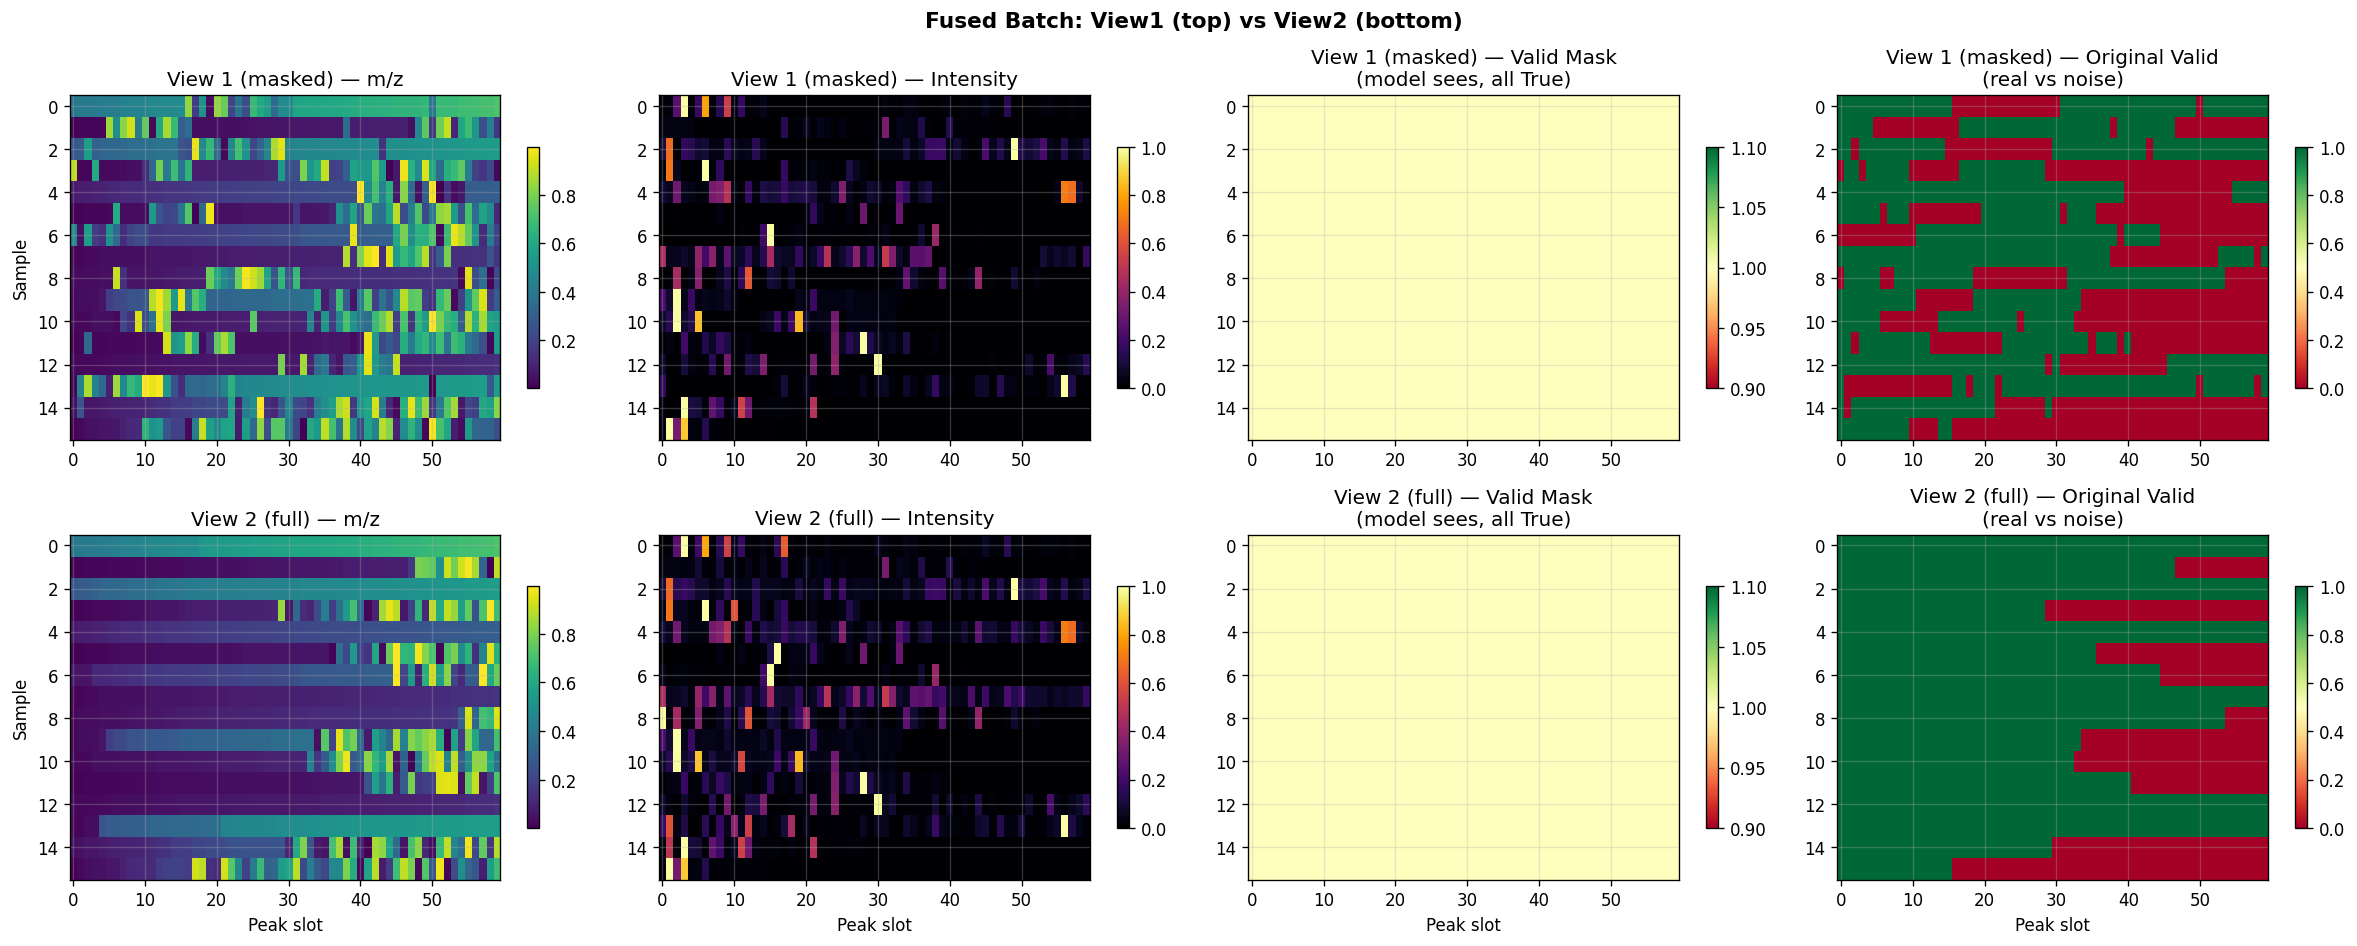

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Fused Batch: View1 (top) vs View2 (bottom)', fontsize=13, fontweight='bold')

fused_mz = aug_batch['fused_mz']      # [2B, N]
fused_int = aug_batch['fused_intensity']
fused_valid = aug_batch['fused_valid_mask']           # all True (model sees)
fused_orig_valid = aug_batch['fused_original_valid_mask']  # real peaks vs noise

for row, (label, start) in enumerate([('View 1 (masked)', 0), ('View 2 (full)', B)]):
    sl = slice(start, start + B)
    
    ax = axes[row, 0]
    im = ax.imshow(fused_mz[sl], aspect='auto', cmap='viridis', interpolation='nearest')
    ax.set_title(f'{label} — m/z')
    ax.set_ylabel('Sample')
    plt.colorbar(im, ax=ax, shrink=0.7)
    
    ax = axes[row, 1]
    im = ax.imshow(fused_int[sl], aspect='auto', cmap='inferno', interpolation='nearest')
    ax.set_title(f'{label} — Intensity')
    plt.colorbar(im, ax=ax, shrink=0.7)
    
    ax = axes[row, 2]
    im = ax.imshow(fused_valid[sl].astype(float), aspect='auto', cmap='RdYlGn', interpolation='nearest')
    ax.set_title(f'{label} — Valid Mask\n(model sees, all True)')
    plt.colorbar(im, ax=ax, shrink=0.7)

    ax = axes[row, 3]
    im = ax.imshow(fused_orig_valid[sl].astype(float), aspect='auto', cmap='RdYlGn', interpolation='nearest')
    ax.set_title(f'{label} — Original Valid\n(real vs noise)')
    plt.colorbar(im, ax=ax, shrink=0.7)

for ax in axes[1]:
    ax.set_xlabel('Peak slot')

plt.tight_layout()
plt.savefig('notebooks/fig_fused_batch.png', bbox_inches='tight')
plt.show()

## 6. Jitter Effect Visualization

Compare the same spectrum before and after jitter (view2, which has no masking, just jitter).

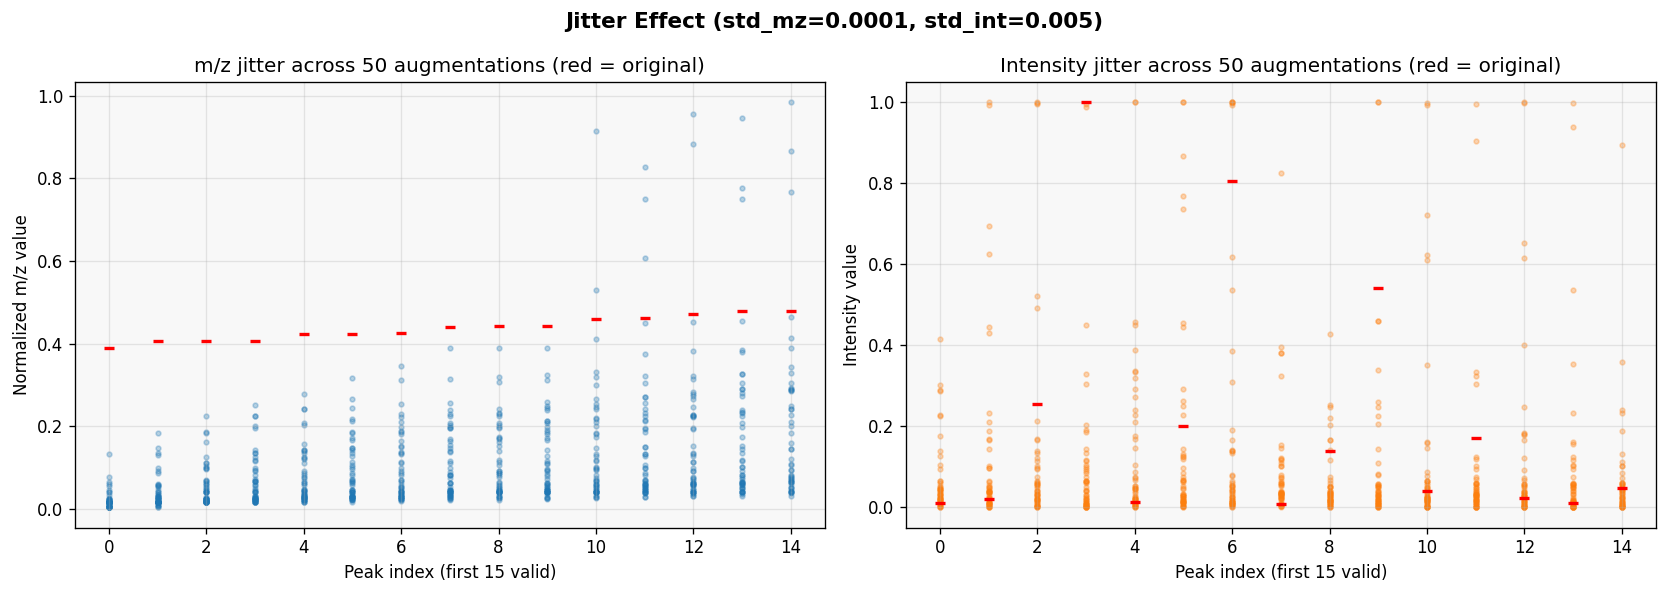

In [9]:
# Run augmentation multiple times to see jitter distribution
n_runs = 50
sample_idx = 0

orig_mz_s = raw_batch['peak_mz'][sample_idx]
orig_int_s = raw_batch['peak_intensity'][sample_idx]
orig_valid_s = raw_batch['peak_valid_mask'][sample_idx].astype(bool)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Jitter Effect (std_mz={cfg.sigreg_mz_jitter_std}, std_int={cfg.sigreg_intensity_jitter_std})',
             fontsize=13, fontweight='bold')

# Collect multiple jittered versions from view2
jittered_mz_all = []
jittered_int_all = []
for _ in range(n_runs):
    ab = next(aug_ds.as_numpy_iterator())
    jittered_mz_all.append(ab['fused_mz'][B + sample_idx])
    jittered_int_all.append(ab['fused_intensity'][B + sample_idx])

jittered_mz_all = np.stack(jittered_mz_all)
jittered_int_all = np.stack(jittered_int_all)

# m/z jitter
ax = axes[0]
valid_peaks = np.where(orig_valid_s)[0][:15]  # first 15 valid peaks
for i, pk in enumerate(valid_peaks):
    vals = jittered_mz_all[:, pk]
    orig_val = orig_mz_s[pk]
    ax.scatter(np.full_like(vals, i), vals, alpha=0.3, s=8, c='C0')
    ax.scatter(i, orig_val, c='red', s=30, marker='_', linewidths=2, zorder=5)
ax.set_xlabel('Peak index (first 15 valid)')
ax.set_ylabel('Normalized m/z value')
ax.set_title('m/z jitter across 50 augmentations (red = original)')

# Intensity jitter
ax = axes[1]
for i, pk in enumerate(valid_peaks):
    vals = jittered_int_all[:, pk]
    orig_val = orig_int_s[pk]
    ax.scatter(np.full_like(vals, i), vals, alpha=0.3, s=8, c='C1')
    ax.scatter(i, orig_val, c='red', s=30, marker='_', linewidths=2, zorder=5)
ax.set_xlabel('Peak index (first 15 valid)')
ax.set_ylabel('Intensity value')
ax.set_title('Intensity jitter across 50 augmentations (red = original)')

plt.tight_layout()
plt.savefig('notebooks/fig_jitter.png', bbox_inches='tight')
plt.show()

## 7. Fourier Features — What the Encoder Embeds

The encoder first applies `FourierFeatures` to normalized m/z values, producing a [B, N, 128] tensor of sin/cos features at log-spaced frequencies from 1 Hz to 5000 Hz.

/tmp/ipykernel_3531079/2689979113.py:11: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  sample_mz = torch.from_numpy(raw_batch['peak_mz'][0:1]).float()  # [1, 60]


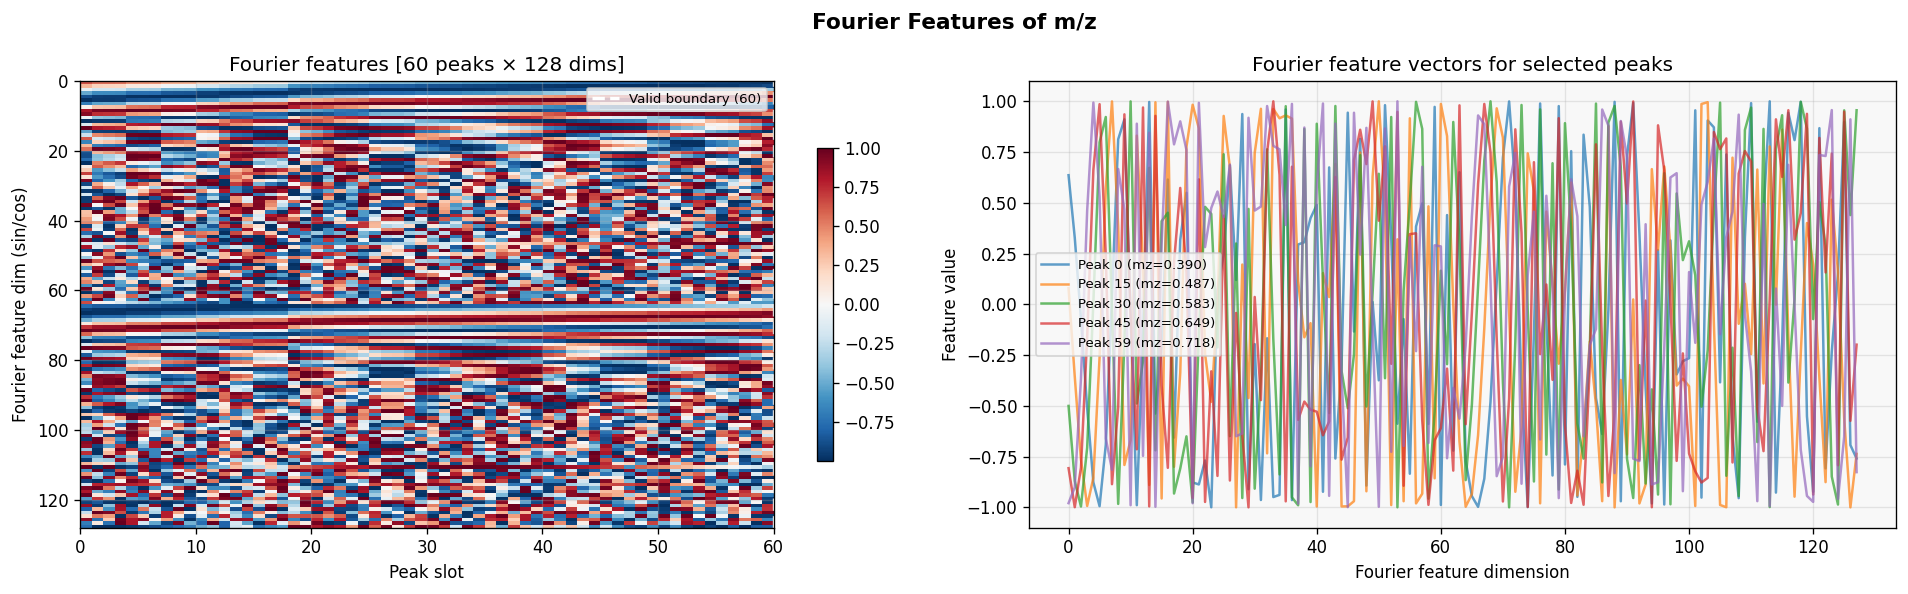

In [10]:
from models.model import FourierFeatures

ff = FourierFeatures(
    num_frequencies=cfg.mz_fourier_num_frequencies,
    min_freq=cfg.mz_fourier_min_freq,
    max_freq=cfg.mz_fourier_max_freq,
    learnable=cfg.mz_fourier_learnable,
)

# Apply to a single sample's m/z
sample_mz = torch.from_numpy(raw_batch['peak_mz'][0:1]).float()  # [1, 60]
sample_valid = raw_batch['peak_valid_mask'][0].astype(bool)

with torch.no_grad():
    fourier_out = ff(sample_mz)  # [1, 60, 128]

fourier_np = fourier_out[0].numpy()  # [60, 128]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Fourier Features of m/z', fontsize=13, fontweight='bold')

# Full heatmap
ax = axes[0]
im = ax.imshow(fourier_np.T, aspect='auto', cmap='RdBu_r', interpolation='nearest',
               extent=[0, _NUM_PEAKS_OUTPUT, 128, 0])
ax.set_xlabel('Peak slot')
ax.set_ylabel('Fourier feature dim (sin/cos)')
ax.set_title('Fourier features [60 peaks × 128 dims]')
# Mark valid/invalid boundary
n_valid = sample_valid.sum()
ax.axvline(n_valid, color='white', ls='--', lw=2, label=f'Valid boundary ({n_valid})')
ax.legend(loc='upper right', fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.7)

# Lineplot: fourier response for a few specific peaks
ax = axes[1]
valid_peaks = np.where(sample_valid)[0]
for pk_i in [0, len(valid_peaks)//4, len(valid_peaks)//2, 3*len(valid_peaks)//4, len(valid_peaks)-1]:
    pk = valid_peaks[pk_i]
    mz_val = raw_batch['peak_mz'][0, pk]
    ax.plot(fourier_np[pk], alpha=0.7, label=f'Peak {pk} (mz={mz_val:.3f})')
ax.set_xlabel('Fourier feature dimension')
ax.set_ylabel('Feature value')
ax.set_title('Fourier feature vectors for selected peaks')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('notebooks/fig_fourier.png', bbox_inches='tight')
plt.show()

## 8. End-to-End Single-Sample Journey

One spectrum through every pipeline stage in a single figure.

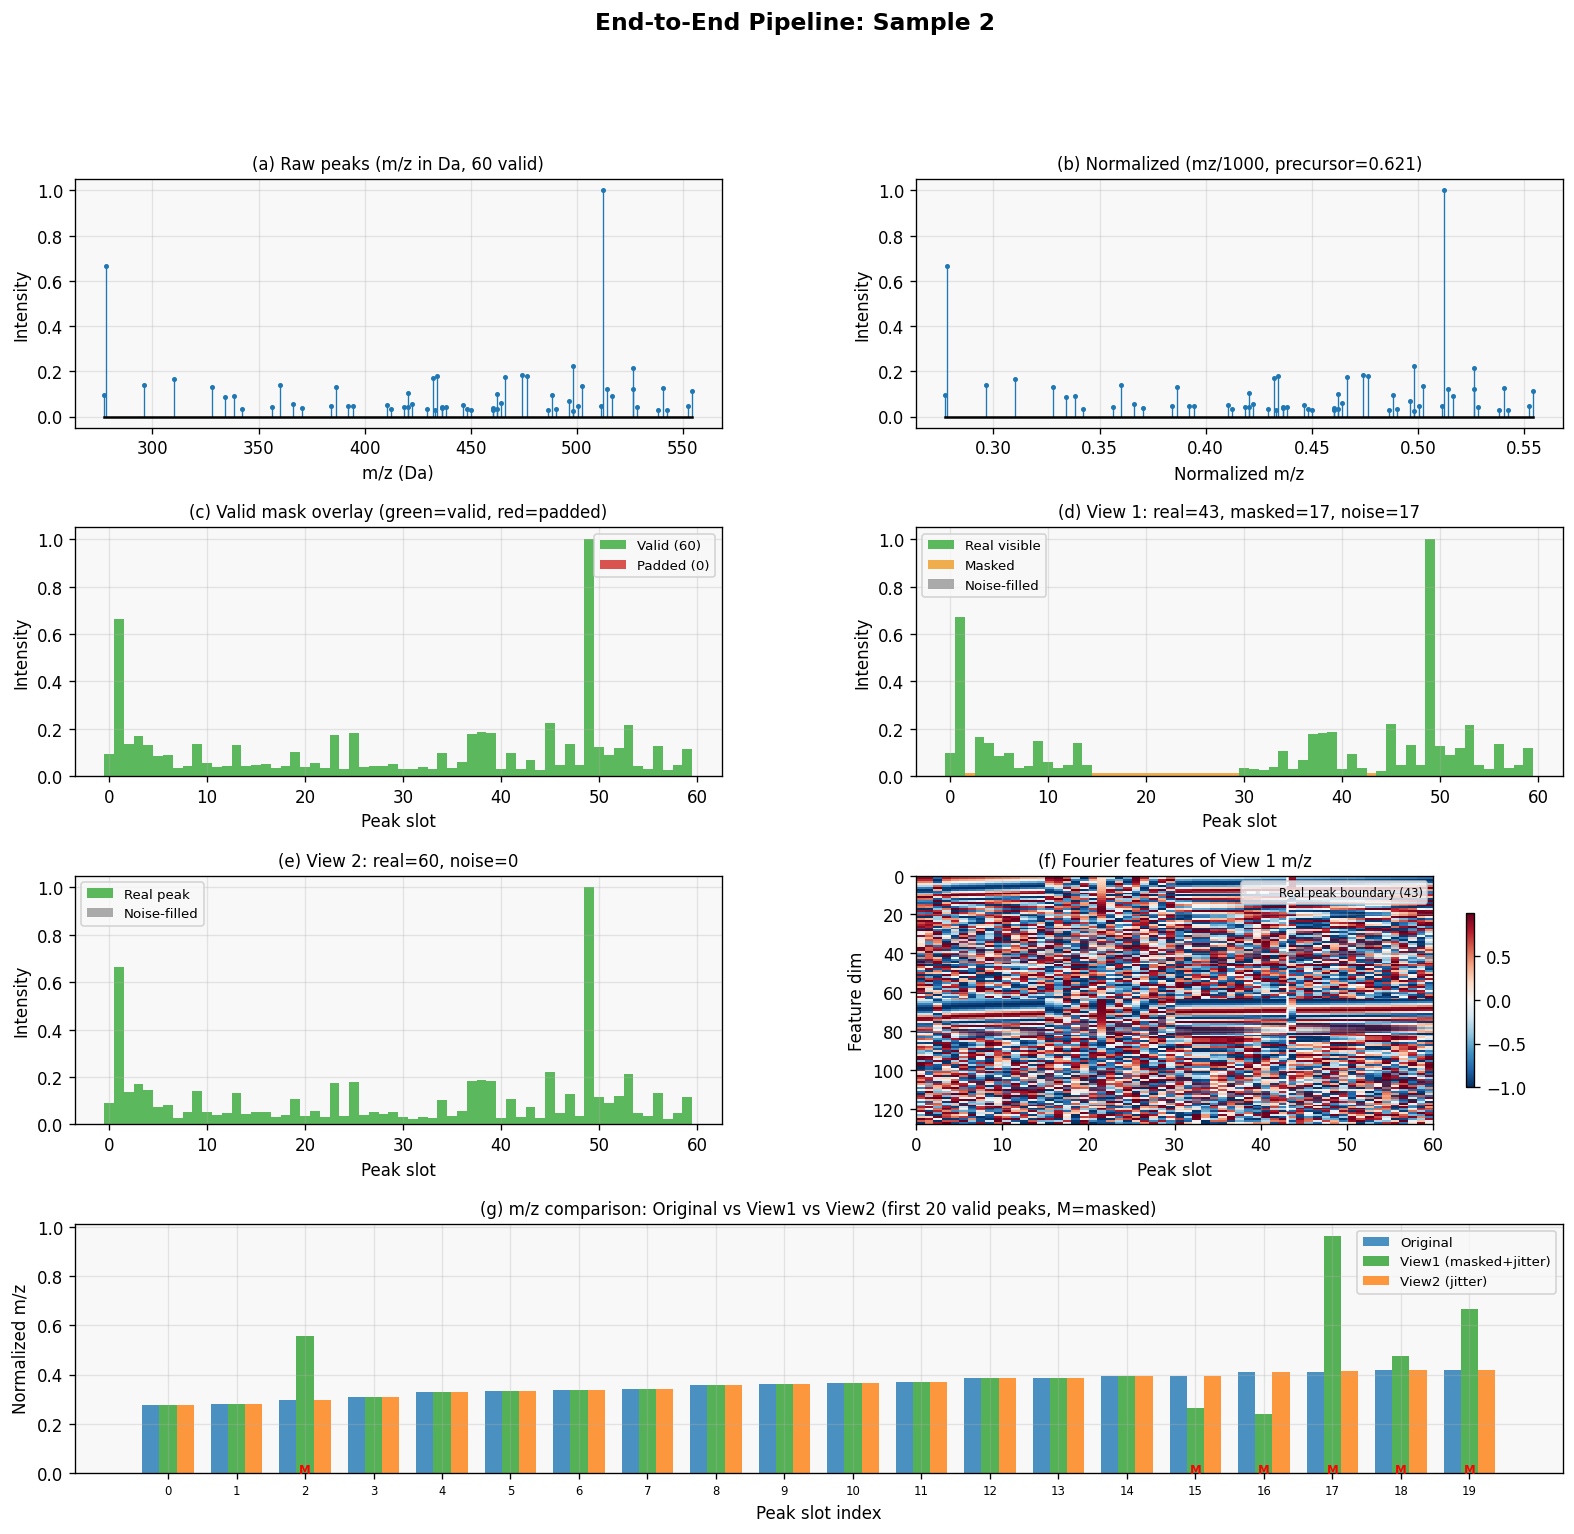

In [11]:
idx = 2

fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.4, wspace=0.3)
fig.suptitle(f'End-to-End Pipeline: Sample {idx}', fontsize=14, fontweight='bold', y=0.98)

o_mz = raw_batch['peak_mz'][idx]
o_int = raw_batch['peak_intensity'][idx]
o_valid = raw_batch['peak_valid_mask'][idx].astype(bool)
o_prec = raw_batch['precursor_mz'][idx]
o_raw_mz = raw_batch['mz'][idx]  # un-normalized mz
o_raw_int = raw_batch['intensity'][idx]

v1_mz_s = aug_batch['fused_mz'][idx]
v1_int_s = aug_batch['fused_intensity'][idx]
v1_orig_valid_s = aug_batch['fused_original_valid_mask'][idx].astype(bool)
v1_masked_s = aug_batch['fused_masked_positions'][idx].astype(bool)

v2_mz_s = aug_batch['fused_mz'][B + idx]
v2_int_s = aug_batch['fused_intensity'][B + idx]
v2_orig_valid_s = aug_batch['fused_original_valid_mask'][B + idx].astype(bool)

# (a) Raw spectrum (un-normalized)
ax = fig.add_subplot(gs[0, 0])
v_idx = np.where(o_valid)[0]
if len(v_idx) > 0:
    markerline, stemlines, baseline = ax.stem(
        o_raw_mz[v_idx], o_raw_int[v_idx],
        linefmt='C0-', markerfmt='C0o', basefmt='k-'
    )
    stemlines.set_linewidth(0.8)
    markerline.set_markersize(2)
ax.set_title(f'(a) Raw peaks (m/z in Da, {len(v_idx)} valid)', fontsize=10)
ax.set_xlabel('m/z (Da)')
ax.set_ylabel('Intensity')

# (b) Normalized spectrum
ax = fig.add_subplot(gs[0, 1])
if len(v_idx) > 0:
    markerline, stemlines, baseline = ax.stem(
        o_mz[v_idx], o_int[v_idx],
        linefmt='C0-', markerfmt='C0o', basefmt='k-'
    )
    stemlines.set_linewidth(0.8)
    markerline.set_markersize(2)
ax.set_title(f'(b) Normalized (mz/1000, precursor={o_prec:.3f})', fontsize=10)
ax.set_xlabel('Normalized m/z')
ax.set_ylabel('Intensity')

# (c) Valid mask + padding indicator
ax = fig.add_subplot(gs[1, 0])
colors = ['#5cb85c' if v else '#d9534f' for v in o_valid]
ax.bar(range(_NUM_PEAKS_OUTPUT), o_int, color=colors, width=1.0, edgecolor='none')
ax.set_title('(c) Valid mask overlay (green=valid, red=padded)', fontsize=10)
ax.set_xlabel('Peak slot')
ax.set_ylabel('Intensity')
ax.legend(handles=[
    Patch(facecolor='#5cb85c', label=f'Valid ({o_valid.sum()})'),
    Patch(facecolor='#d9534f', label=f'Padded ({(~o_valid).sum()})'),
], fontsize=8)

# (d) View1: masked + jittered + noise-filled (use original valid mask for coloring)
ax = fig.add_subplot(gs[1, 1])
state_colors = []
for j in range(_NUM_PEAKS_OUTPUT):
    if v1_masked_s[j]:
        state_colors.append('#f0ad4e')  # orange = masked
    elif v1_orig_valid_s[j]:
        state_colors.append('#5cb85c')  # green = real peak visible
    else:
        state_colors.append('#aaaaaa')  # gray = noise-filled
heights = v1_int_s.copy()
heights = np.where(v1_masked_s, 0.015, heights)  # small marker for masked
ax.bar(range(_NUM_PEAKS_OUTPUT), heights, color=state_colors, width=1.0, edgecolor='none')
real_visible = (v1_orig_valid_s & ~v1_masked_s).sum()
noise_count = (~v1_orig_valid_s).sum()
ax.set_title(f'(d) View 1: real={real_visible}, masked={v1_masked_s.sum()}, noise={noise_count}', fontsize=10)
ax.set_xlabel('Peak slot')
ax.set_ylabel('Intensity')
ax.legend(handles=[
    Patch(facecolor='#5cb85c', label='Real visible'),
    Patch(facecolor='#f0ad4e', label='Masked'),
    Patch(facecolor='#aaaaaa', label='Noise-filled'),
], fontsize=8)

# (e) View2: jittered only + noise-filled
ax = fig.add_subplot(gs[2, 0])
v2_colors = ['#5cb85c' if v else '#aaaaaa' for v in v2_orig_valid_s]
ax.bar(range(_NUM_PEAKS_OUTPUT), v2_int_s,
       color=v2_colors, width=1.0, edgecolor='none')
ax.set_title(f'(e) View 2: real={v2_orig_valid_s.sum()}, noise={(~v2_orig_valid_s).sum()}', fontsize=10)
ax.set_xlabel('Peak slot')
ax.set_ylabel('Intensity')
ax.legend(handles=[
    Patch(facecolor='#5cb85c', label='Real peak'),
    Patch(facecolor='#aaaaaa', label='Noise-filled'),
], fontsize=8)

# (f) Fourier features of view1 mz
ax = fig.add_subplot(gs[2, 1])
v1_mz_torch = torch.from_numpy(v1_mz_s[np.newaxis]).float()
with torch.no_grad():
    ff_v1 = ff(v1_mz_torch)[0].numpy()
im = ax.imshow(ff_v1.T, aspect='auto', cmap='RdBu_r', interpolation='nearest',
               extent=[0, _NUM_PEAKS_OUTPUT, 128, 0])
n_v1_orig_valid = v1_orig_valid_s.sum()
ax.axvline(n_v1_orig_valid, color='white', ls='--', lw=1.5, label=f'Real peak boundary ({n_v1_orig_valid})')
ax.set_title('(f) Fourier features of View 1 m/z', fontsize=10)
ax.set_xlabel('Peak slot')
ax.set_ylabel('Feature dim')
ax.legend(loc='upper right', fontsize=7)
plt.colorbar(im, ax=ax, shrink=0.7)

# (g) Side-by-side m/z comparison: original vs view1 vs view2
ax = fig.add_subplot(gs[3, :])
valid_slots = np.where(o_valid)[0][:20]
x = np.arange(len(valid_slots))
w = 0.25
ax.bar(x - w, o_mz[valid_slots], w, label='Original', color='C0', alpha=0.8)
ax.bar(x, v1_mz_s[valid_slots], w, label='View1 (masked+jitter)', color='C2', alpha=0.8)
ax.bar(x + w, v2_mz_s[valid_slots], w, label='View2 (jitter)', color='C1', alpha=0.8)
# Mark masked slots
for i, slot in enumerate(valid_slots):
    if v1_masked_s[slot]:
        ax.annotate('M', (i, 0), fontsize=7, ha='center', color='red', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in valid_slots], fontsize=7)
ax.set_xlabel('Peak slot index')
ax.set_ylabel('Normalized m/z')
ax.set_title('(g) m/z comparison: Original vs View1 vs View2 (first 20 valid peaks, M=masked)', fontsize=10)
ax.legend(fontsize=8)

plt.savefig('notebooks/fig_pipeline_journey.png', bbox_inches='tight')
plt.show()

## 9. Batch Statistics Summary

Aggregate statistics of the fused batch that enters the model.

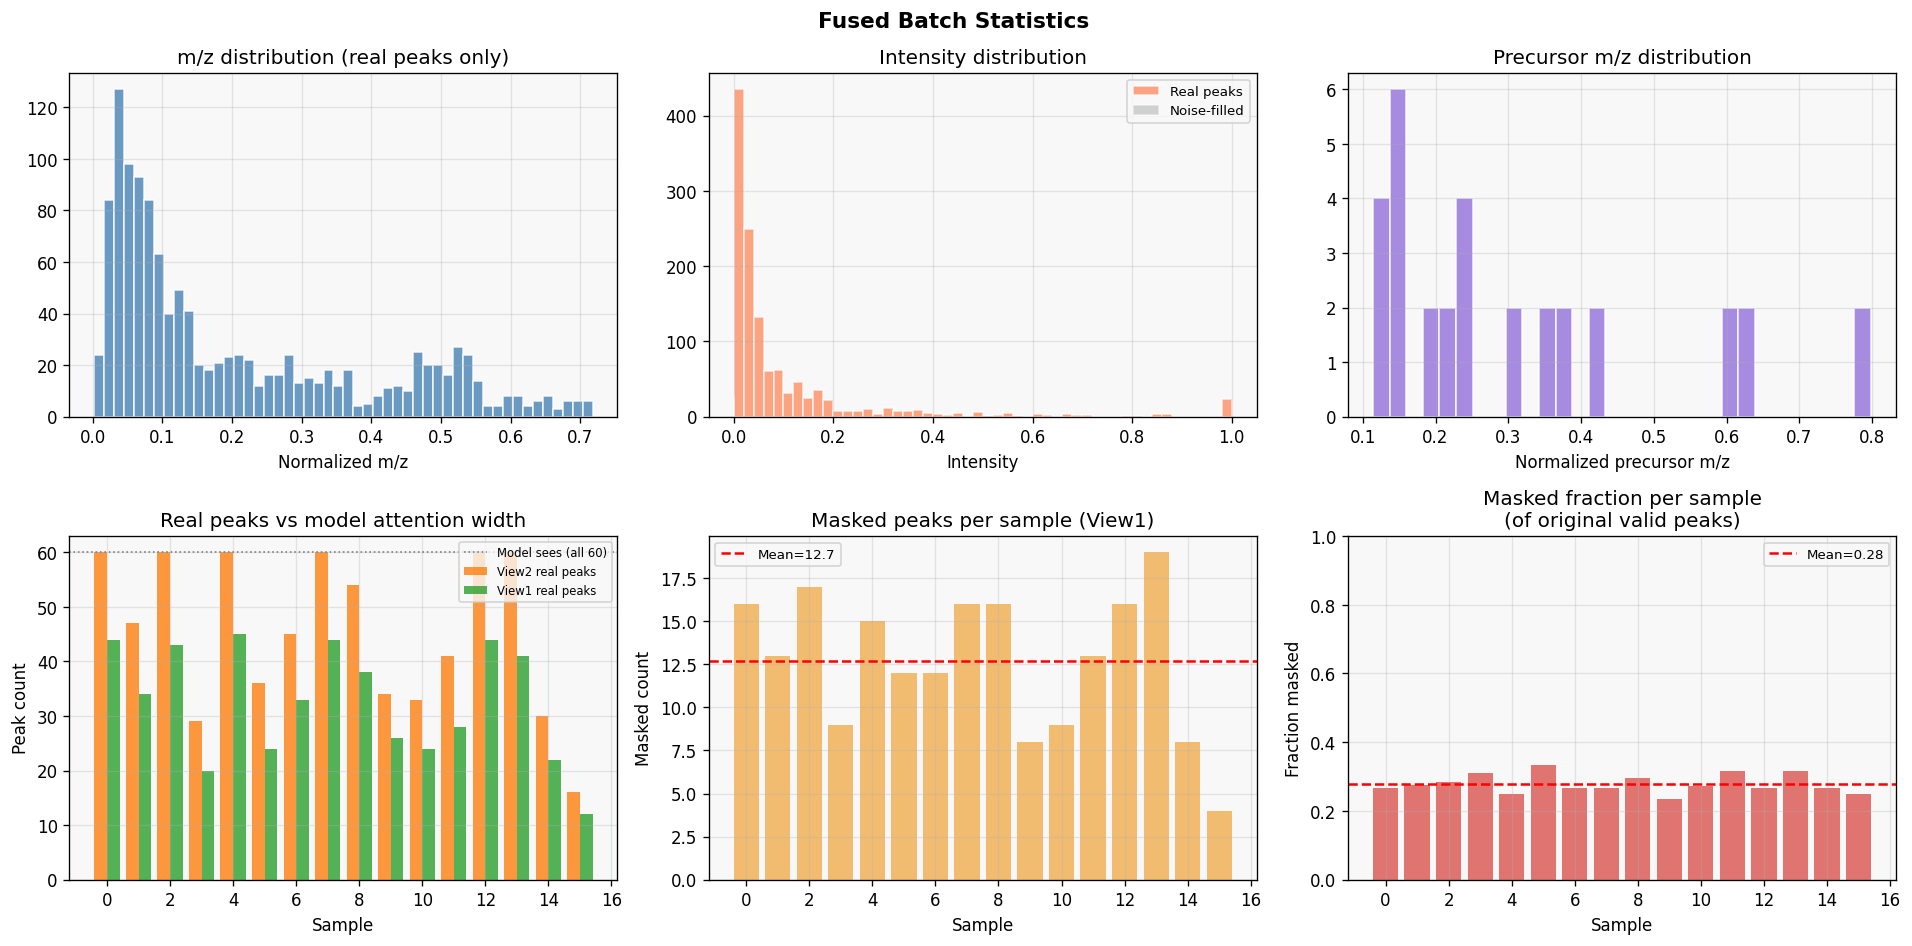


Summary:
  Batch shape: fused_mz=(32, 60), fused_intensity=(32, 60)
  View1 masked fraction (reported): 0.2797
  Model valid mask (all True): True
  View1 avg real peaks: 32.6 / 60
  View2 avg real peaks: 45.3 / 60
  Avg noise-filled per sample (view2): 14.7
  Avg masked per sample: 12.7
  m/z range (real peaks): [0.0026, 0.7175]
  Intensity range (real peaks): [0.0000, 1.0000]
  Noise intensity range: [0.000302, 0.001100]


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Fused Batch Statistics', fontsize=13, fontweight='bold')

fmz = aug_batch['fused_mz']
fi = aug_batch['fused_intensity']
fv = aug_batch['fused_valid_mask']             # all True (model sees)
fov = aug_batch['fused_original_valid_mask']   # real peaks vs noise
fm = aug_batch['fused_masked_positions']
fp = aug_batch['fused_precursor_mz']

# (a) m/z distribution (real peaks only, using original valid mask)
ax = axes[0, 0]
real_peak_mask = fov.astype(bool)
valid_mz = fmz[real_peak_mask]
ax.hist(valid_mz, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_title('m/z distribution (real peaks only)')
ax.set_xlabel('Normalized m/z')

# (b) Intensity distribution: real peaks vs noise-filled
ax = axes[0, 1]
valid_int = fi[real_peak_mask]
noise_int = fi[~real_peak_mask]
ax.hist(valid_int, bins=50, color='coral', edgecolor='white', alpha=0.7, label='Real peaks')
if len(noise_int) > 0:
    ax.hist(noise_int, bins=50, color='#aaaaaa', edgecolor='white', alpha=0.5, label='Noise-filled')
ax.set_title('Intensity distribution')
ax.set_xlabel('Intensity')
ax.legend(fontsize=8)

# (c) Precursor m/z distribution
ax = axes[0, 2]
ax.hist(fp, bins=30, color='mediumpurple', edgecolor='white', alpha=0.8)
ax.set_title('Precursor m/z distribution')
ax.set_xlabel('Normalized precursor m/z')

# (d) Real peak count per sample: view1 vs view2 (using original valid mask)
ax = axes[1, 0]
v1_orig_counts = fov[:B].sum(axis=1)
v2_orig_counts = fov[B:].sum(axis=1)
v1_model_counts = fv[:B].sum(axis=1)  # all 60 (model sees all)
x = np.arange(B)
ax.bar(x - 0.2, v2_orig_counts, 0.4, label='View2 real peaks', color='C1', alpha=0.8)
ax.bar(x + 0.2, v1_orig_counts, 0.4, label='View1 real peaks', color='C2', alpha=0.8)
ax.axhline(_NUM_PEAKS_OUTPUT, color='gray', ls=':', lw=1, label=f'Model sees (all {_NUM_PEAKS_OUTPUT})')
ax.set_title('Real peaks vs model attention width')
ax.set_xlabel('Sample')
ax.set_ylabel('Peak count')
ax.legend(fontsize=7)

# (e) Masked count per sample
ax = axes[1, 1]
m_counts = fm[:B].sum(axis=1)
ax.bar(range(B), m_counts, color='#f0ad4e', alpha=0.8)
ax.axhline(m_counts.mean(), color='red', ls='--', label=f'Mean={m_counts.mean():.1f}')
ax.set_title('Masked peaks per sample (View1)')
ax.set_xlabel('Sample')
ax.set_ylabel('Masked count')
ax.legend(fontsize=8)

# (f) Masked fraction per sample (relative to original valid peaks)
ax = axes[1, 2]
orig_counts = raw_batch['peak_valid_mask'][:B].sum(axis=1)
safe_counts = np.maximum(orig_counts, 1)
frac = m_counts / safe_counts
ax.bar(range(B), frac, color='#d9534f', alpha=0.8)
ax.axhline(frac.mean(), color='red', ls='--', label=f'Mean={frac.mean():.2f}')
ax.set_title('Masked fraction per sample\n(of original valid peaks)')
ax.set_xlabel('Sample')
ax.set_ylabel('Fraction masked')
ax.set_ylim(0, 1)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('notebooks/fig_batch_stats.png', bbox_inches='tight')
plt.show()

print(f"\nSummary:")
print(f"  Batch shape: fused_mz={fmz.shape}, fused_intensity={fi.shape}")
print(f"  View1 masked fraction (reported): {aug_batch['view1_masked_fraction']:.4f}")
print(f"  Model valid mask (all True): {fv.all()}")
print(f"  View1 avg real peaks: {v1_orig_counts.mean():.1f} / {_NUM_PEAKS_OUTPUT}")
print(f"  View2 avg real peaks: {v2_orig_counts.mean():.1f} / {_NUM_PEAKS_OUTPUT}")
print(f"  Avg noise-filled per sample (view2): {(_NUM_PEAKS_OUTPUT - v2_orig_counts).mean():.1f}")
print(f"  Avg masked per sample: {m_counts.mean():.1f}")
print(f"  m/z range (real peaks): [{valid_mz.min():.4f}, {valid_mz.max():.4f}]")
print(f"  Intensity range (real peaks): [{valid_int.min():.4f}, {valid_int.max():.4f}]")
if len(noise_int) > 0:
    print(f"  Noise intensity range: [{noise_int.min():.6f}, {noise_int.max():.6f}]")